In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, HDBSCAN
import matplotlib.pyplot as plt
import plotly.express as px
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "vscode"

In [4]:
df = pd.read_csv("C:\\Users\\nicob\\One Drive Uniandes\\OneDrive - Universidad de los Andes\\Doctorado\\proyecto\\clusterization_project\\data\\datos_resultados_modularizado\\datos_clusterizados_todos_5derr_spur.csv")
df['division'] = df['coordenada_ra'].astype(str) + "_" + df['coordenada_dec'].astype(str)
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc
# Crear objetos SkyCoord vectorizados
coords = SkyCoord(ra=df['ra'].values * u.degree,
                  dec=df['dec'].values * u.degree,
                  distance=df['distance_pc'].values * u.pc,
                  frame='icrs')

# Extraer coordenadas cartesianas
df['x_pc'] = coords.cartesian.x.value
df['y_pc'] = coords.cartesian.y.value
df['z_pc'] = coords.cartesian.z.value
df['probabilidad'] = df['ConteoAgrupaciones']/400

In [5]:
df['l'] = coords.galactic.l.degree  # longitud galáctica
df['b'] = coords.galactic.b.degree 
df['l_rad'] = np.radians(df['l'].values - 180)   # longitud galáctica
df['b_rad'] = np.radians(df['b'].values)

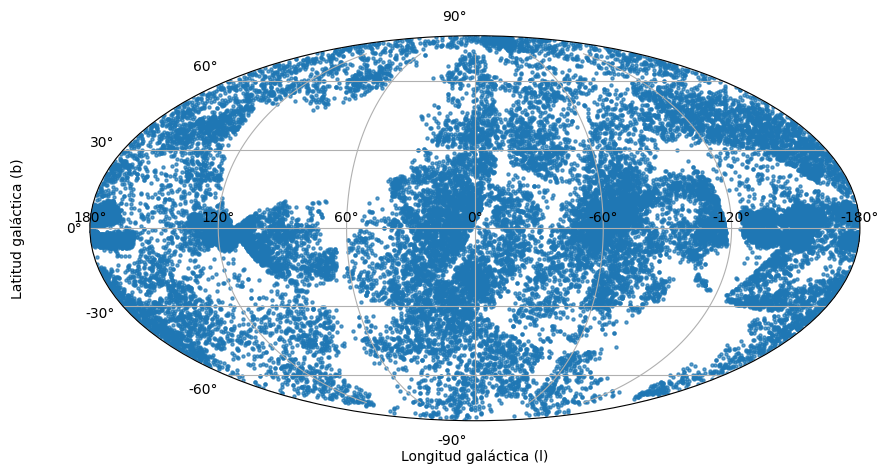

In [6]:
l = df['l'].values
b = df['b'].values

# Convertir a radianes para Mollweide
l_rad = np.radians(l - 180)  # Recentrar en 0°
b_rad = np.radians(b)

# Crear figura
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

# Scatter plot
ax.scatter(l_rad, b_rad, s=5, alpha=0.7)

# Grid cada 30° latitud, 60° longitud
ax.set_xticks(np.radians(np.arange(-180, 181, 60)))
ax.set_yticks(np.radians(np.arange(-90, 91, 30)))

ax.set_xticklabels(['180°', '120°', '60°', '0°', '-60°', '-120°', '-180°'])
ax.set_yticklabels(['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°'])

ax.grid(True)
ax.set_xlabel('Longitud galáctica (l)', labelpad=20)
ax.set_ylabel('Latitud galáctica (b)', labelpad=30)
plt.show()

In [7]:
def silhouette_por_cluster_dataframe(df, cluster_col='cluster', feature_cols=None):
    # Excluir ruido
    df_valido = df[df[cluster_col] != -1].copy()

    if feature_cols is None:
        # Detectar columnas numéricas automáticamente si no se especifican
        feature_cols = df_valido.select_dtypes(include=['float64', 'int64']).columns.tolist()
        feature_cols.remove(cluster_col)

    X = df_valido[feature_cols].values
    labels = df_valido[cluster_col].values

    # Calcular silhouette por muestra
    sil_values = silhouette_samples(X, labels)

    df_valido['silhouette'] = sil_values

    # Agrupar por clúster y calcular promedio
    silhouette_mean = df_valido.groupby(cluster_col)['silhouette'].mean()

    return silhouette_mean

def r2_por_cluster_dataframe(df, cluster_col='cluster', x_col='b_v', y_col='phot_g_mean_mag', calcular_rmse=True, calcular_residual_std=True):
    df_valido = df[df[cluster_col] != -1].copy()
    resultados = []

    for cluster, grupo in df_valido.groupby(cluster_col):
        if len(grupo) < 2:
            continue

        X = grupo[[x_col]].values
        y = grupo[y_col].values

        modelo = LinearRegression().fit(X, y)
        y_pred = modelo.predict(X)
        r2 = r2_score(y, y_pred)**2 # modificado

        resultado_cluster = {
            cluster_col: cluster,
            'r2': r2
        }

        if calcular_rmse:
            rmse = mean_squared_error(y, y_pred)
            resultado_cluster[f'rmse_{y_col}_vs_{x_col}'] = rmse

        if calcular_residual_std:
            residuos = y - y_pred
            std_residuos = np.std(residuos)
            resultado_cluster[f'std_residuos_{y_col}_vs_{x_col}'] = std_residuos

        resultados.append(resultado_cluster)

    return pd.DataFrame(resultados)

def dispersion_por_cluster(df, cluster_col='cluster', variable='phot_g_mean_mag', metodo='std'):
    df_valido = df[df[cluster_col] != -1].copy()

    if metodo == 'std':
        dispersion = df_valido.groupby(cluster_col)[variable].std().reset_index()
        dispersion = dispersion.rename(columns={variable: f'dispersion_{variable}_std'})
    elif metodo == 'var':
        dispersion = df_valido.groupby(cluster_col)[variable].var().reset_index()
        dispersion = dispersion.rename(columns={variable: f'dispersion_{variable}_var'})
    elif metodo == 'iqr':
        dispersion = df_valido.groupby(cluster_col).agg(
            Q3=(variable, lambda x: np.percentile(x, 75)),
            Q1=(variable, lambda x: np.percentile(x, 25))
        )
        dispersion['iqr'] = dispersion['Q3'] - dispersion['Q1']
        dispersion = dispersion.reset_index()[[cluster_col, 'iqr']]
        dispersion = dispersion.rename(columns={'iqr': f'dispersion_{variable}_iqr'})
    else:
        raise ValueError("Método no soportado. Usa 'std', 'var' o 'iqr'.")

    return dispersion

def escalar_columnas(df, columnas, nuevo_min=0, nuevo_max=5):
    df_escalado = df.copy()
    for col in columnas:
        min_val = df[col].min()
        max_val = df[col].max()
        if min_val == max_val:
            df_escalado[col + '_esc'] = nuevo_min  # o 0 si no hay variación
        else:
            df_escalado[col + '_esc'] = nuevo_min + (df[col] - min_val) * (nuevo_max - nuevo_min) / (max_val - min_val)
    return df_escalado

def filtrar_clusters_destacados(df, columnas_originales, columnas_escaladas, percentil=0.9):
    df_filtrado = df.copy()

    # Paso 1: Filtrar donde todas las métricas originales sean > 0
    for col in columnas_originales:
        df_filtrado = df_filtrado[df_filtrado[col] > 0]

    # Paso 2: Filtrar donde todas las métricas escaladas estén en el top percentil
    for col in columnas_escaladas:
        umbral = df[col].quantile(percentil)
        df_filtrado = df_filtrado[df_filtrado[col] >= umbral]

    return df_filtrado

In [8]:
nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df['cluster'] = (df['grupo'].astype(str) + df['numeracion'].astype(str)).astype(int)

In [9]:
dff = df[df['cluster']>0].copy()

In [10]:
dff['abs'] = dff['phot_g_mean_mag'] - 5*np.log10(1000/dff['parallax'])+5

In [11]:
feature_cols = ['pmra_norm', 'pmdec_norm','parallax_norm']
silhouette_por_cluster = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=feature_cols).reset_index()
silhouette_por_distancia = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=['x_pc','y_pc','z_pc']).reset_index()
silhouette_por_movimientos = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=['pmra_norm','pmdec_norm']).reset_index()
r2_clusters = r2_por_cluster_dataframe(dff.dropna(subset=['phot_g_mean_mag','bp_rp']), cluster_col='cluster', x_col='bp_rp', y_col='phot_g_mean_mag',calcular_residual_std = False)
dispersion_magnitud = dispersion_por_cluster(dff, variable='phot_g_mean_mag', metodo='std')
probabilidad_cluster = dff.groupby(['cluster']).agg({'probabilidad':'median','source_id':'count'}).reset_index()
silhouette_por_cluster = silhouette_por_cluster\
                        .merge(probabilidad_cluster, how='inner', on=['cluster'])\
                        .merge(silhouette_por_distancia.rename(columns={'silhouette':'silhouette_distancia'}), how='inner', on=['cluster'])\
                        .merge(silhouette_por_movimientos.rename(columns={'silhouette':'silhouette_movimientos'}), how='inner', on=['cluster'])\
                        .merge(r2_clusters, how='inner', on='cluster')\
                        .merge(dispersion_magnitud, how='inner', on='cluster')
# Columnas que vas a escalar
columnas_a_escalar = ['silhouette', 'silhouette_distancia', 'silhouette_movimientos', 'probabilidad', 'r2', "rmse_phot_g_mean_mag_vs_bp_rp"]

# Escalamos al rango 0-5
silhouette_por_cluster = escalar_columnas(silhouette_por_cluster, columnas=columnas_a_escalar)

# Calculamos métrica global como suma de las columnas escaladas
columnas_escaladas = [col + '_esc' for col in columnas_a_escalar]
silhouette_por_cluster = silhouette_por_cluster[silhouette_por_cluster['silhouette_distancia']>0]

In [12]:
silhouette_por_cluster['metrica'] = silhouette_por_cluster[['silhouette_distancia', 'probabilidad', 'r2']].product(axis=1)

In [13]:
# listado de clusters generados
clusters = np.sort(dff['cluster'].unique())
# Crear un colormap con tantos colores como clusters
colormap = cm.get_cmap('Set1', len(clusters))  # o 'tab20', 'nipy_spectral', etc.

# Crear un diccionario de colores para cada cluster
color_dict = {cluster: colormap(i) for i, cluster in enumerate(clusters)}

# Asignar el color correspondiente a cada fila
dff['color'] = dff['cluster'].map(color_dict)

C:\Users\nicob\AppData\Local\Temp\ipykernel_27552\981530115.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Set1', len(clusters))  # o 'tab20', 'nipy_spectral', etc.


In [14]:
# silhouette_por_cluster[(silhouette_por_cluster['silhouette_distancia']>0.)\
                        # &(silhouette_por_cluster['probabilidad']>0.)\
                        # &(silhouette_por_cluster['silhouette_movimientos']>0)]\
silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(20)

,cluster,silhouette,probabilidad,source_id,silhouette_distancia,silhouette_movimientos,r2,rmse_phot_g_mean_mag_vs_bp_rp,dispersion_phot_g_mean_mag_std,silhouette_esc,silhouette_distancia_esc,silhouette_movimientos_esc,probabilidad_esc,r2_esc,rmse_phot_g_mean_mag_vs_bp_rp_esc,metrica
2,8,0.560631,0.79750,506,0.828589,0.242599,0.714502,2.073649,3.659085,4.490877,5.000000,3.276658,5.000000,5.000000,0.949569,0.472142
1,7,0.525649,0.79000,254,0.768188,0.672761,0.564470,3.834053,3.904722,4.359695,4.804786,4.610725,4.952830,3.950097,1.788743,0.342559
0,2,0.590736,0.32500,101,0.697398,0.388215,0.502713,3.021928,3.207893,4.603774,4.575994,3.728258,2.028302,3.517926,1.401608,0.113942
5,13,0.016974,0.63750,196,0.622990,0.039145,0.236709,4.104869,2.816051,2.452125,4.335509,2.645681,3.993711,1.656460,1.917839,0.094010
8,18,0.159133,0.59250,60,0.652547,-0.001339,0.234758,6.251602,3.512376,2.985232,4.431036,2.520127,3.710692,1.642809,2.941174,0.090765
9,20,-0.211997,0.32750,69,0.649026,-0.540180,0.394595,3.716695,3.177181,1.593466,4.419656,0.849010,2.044025,2.761333,1.732799,0.083874
23,113,0.200973,0.31875,94,0.540978,0.181451,0.286951,2.964148,2.526623,3.142135,4.070449,3.087017,1.988994,2.008052,1.374064,0.049481
7,16,0.696394,0.45750,215,0.376002,0.021881,0.093520,7.957814,3.394596,5.000000,3.537253,2.592140,2.861635,0.654441,3.754515,0.016087
3,10,0.081643,0.31500,126,0.096255,-0.022284,0.142179,5.971398,3.108474,2.694638,2.633117,2.455172,1.965409,0.994951,2.807603,0.004311
32,414,-0.013126,0.32500,182,0.557568,-0.067738,0.018345,0.082990,0.323561,2.339250,4.124069,2.314203,2.028302,0.128375,0.000633,0.003324


In [15]:
filtrar_clusters_destacados(silhouette_por_cluster, columnas_a_escalar, columnas_escaladas, percentil=0.4)

,cluster,silhouette,probabilidad,source_id,silhouette_distancia,silhouette_movimientos,r2,rmse_phot_g_mean_mag_vs_bp_rp,dispersion_phot_g_mean_mag_std,silhouette_esc,silhouette_distancia_esc,silhouette_movimientos_esc,probabilidad_esc,r2_esc,rmse_phot_g_mean_mag_vs_bp_rp_esc,metrica
0,2,0.590736,0.32500,101,0.697398,0.388215,0.502713,3.021928,3.207893,4.603774,4.575994,3.728258,2.028302,3.517926,1.401608,0.113942
1,7,0.525649,0.79000,254,0.768188,0.672761,0.564470,3.834053,3.904722,4.359695,4.804786,4.610725,4.952830,3.950097,1.788743,0.342559
2,8,0.560631,0.79750,506,0.828589,0.242599,0.714502,2.073649,3.659085,4.490877,5.000000,3.276658,5.000000,5.000000,0.949569,0.472142
5,13,0.016974,0.63750,196,0.622990,0.039145,0.236709,4.104869,2.816051,2.452125,4.335509,2.645681,3.993711,1.656460,1.917839,0.094010
7,16,0.696394,0.45750,215,0.376002,0.021881,0.093520,7.957814,3.394596,5.000000,3.537253,2.592140,2.861635,0.654441,3.754515,0.016087
23,113,0.200973,0.31875,94,0.540978,0.181451,0.286951,2.964148,2.526623,3.142135,4.070449,3.087017,1.988994,2.008052,1.374064,0.049481


Text(0.5, 0, 'Métrica')

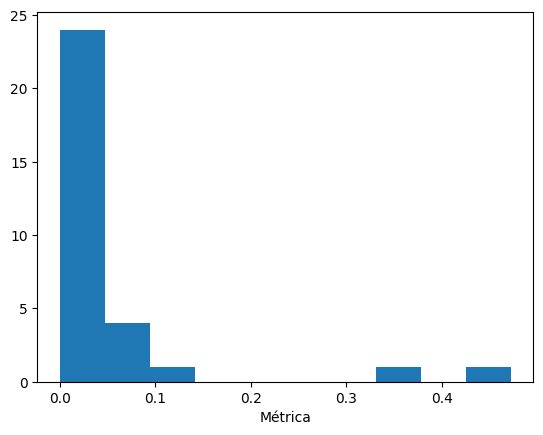

In [16]:
plt.hist(silhouette_por_cluster['metrica'])
plt.xlabel("Métrica")

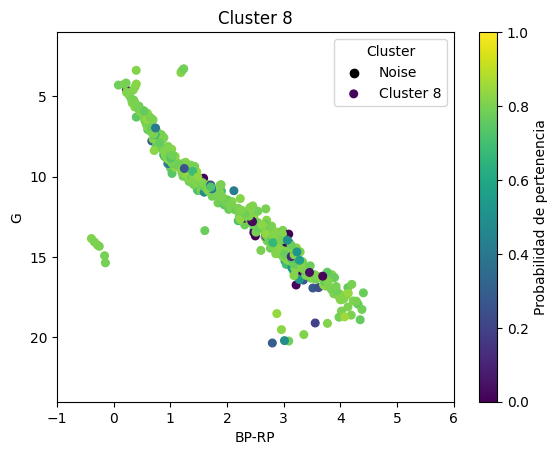

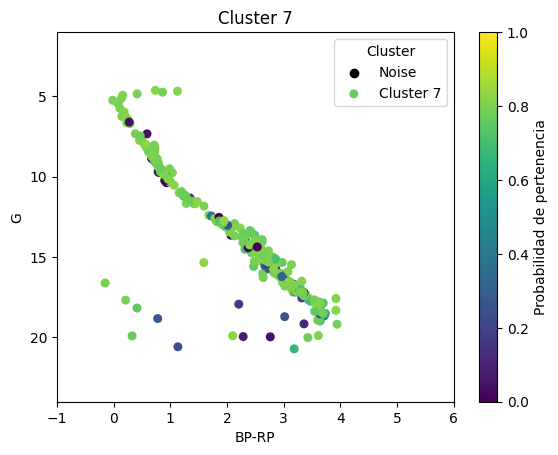

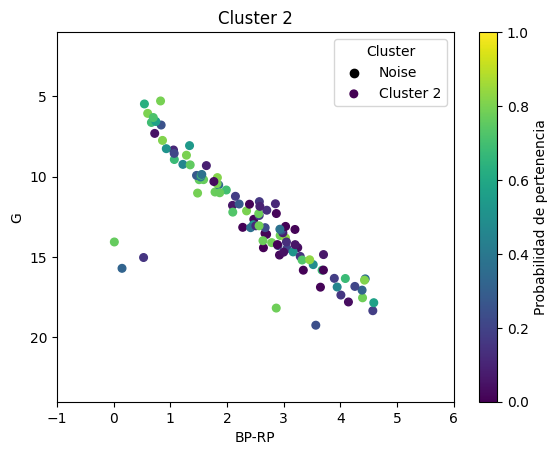

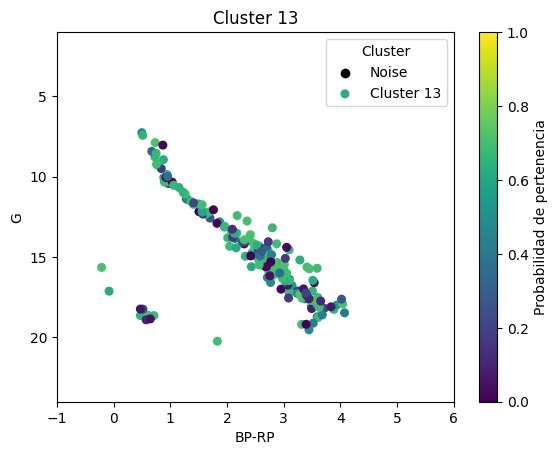

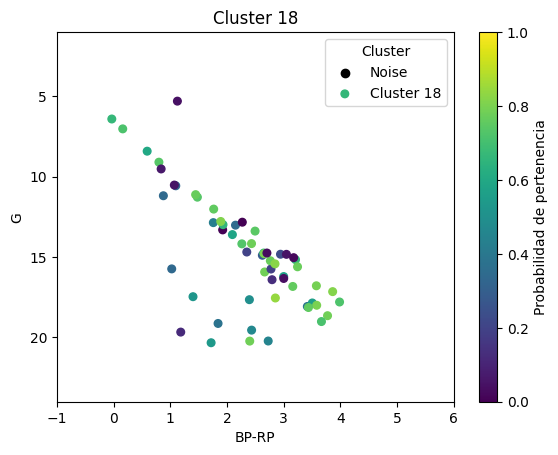

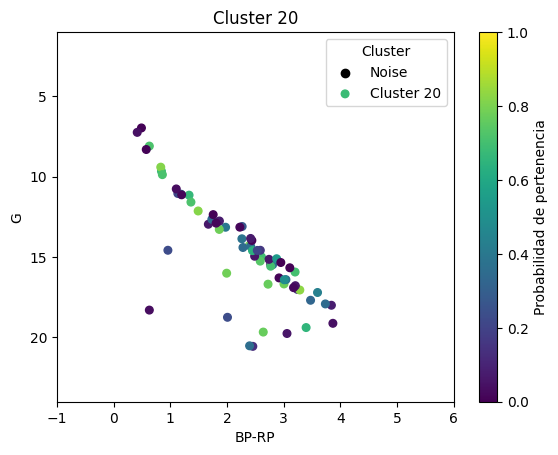

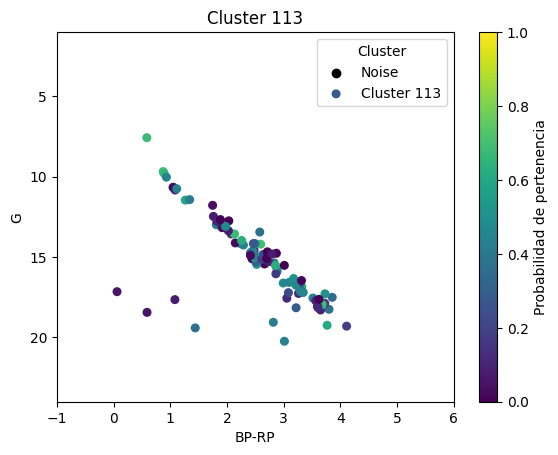

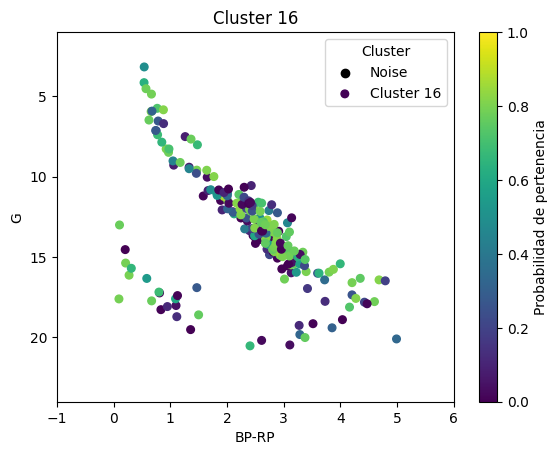

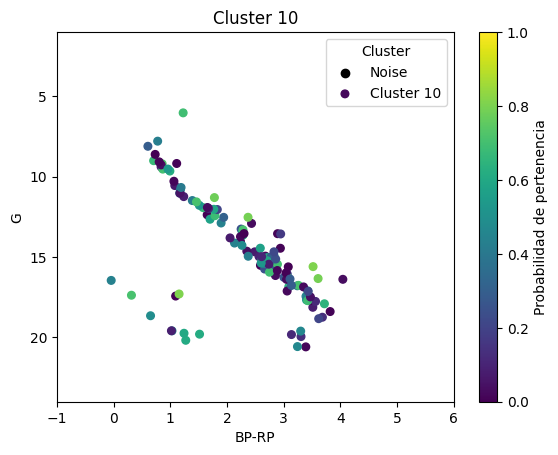

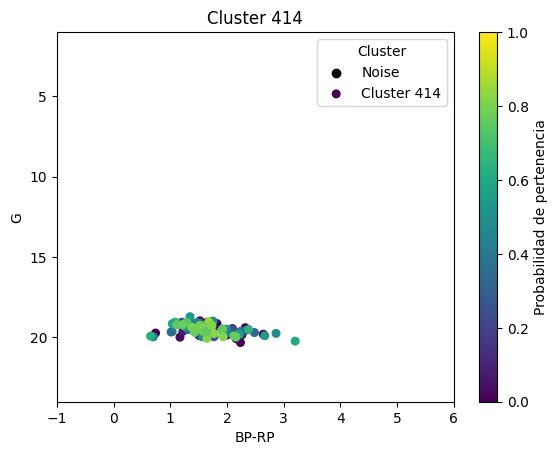

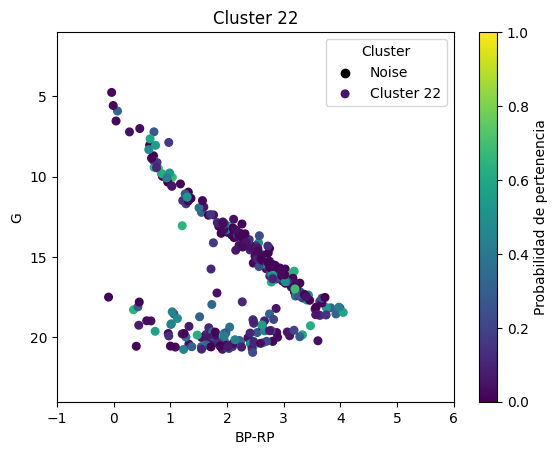

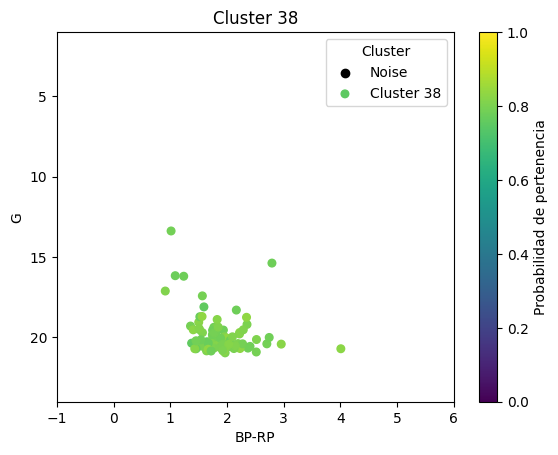

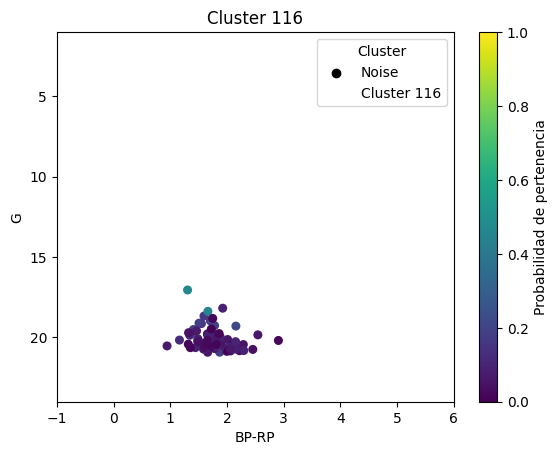

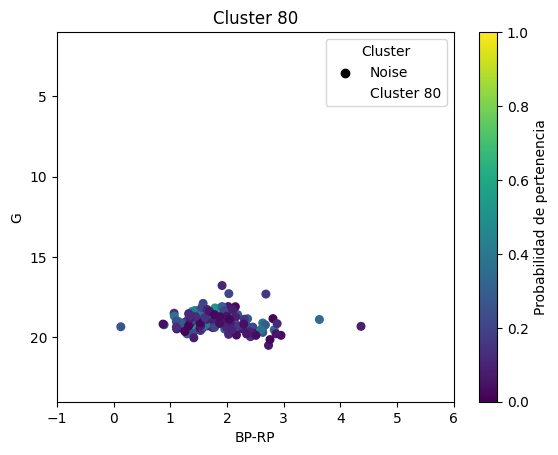

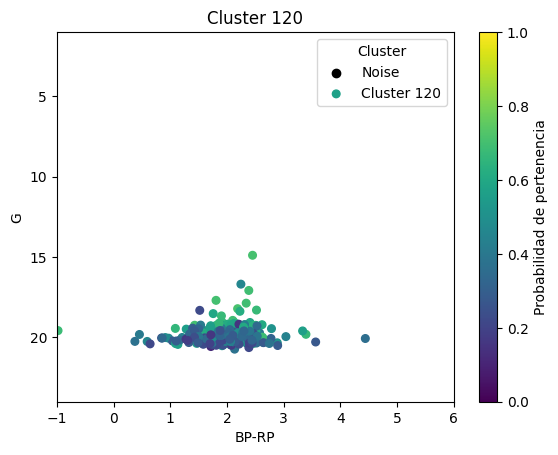

In [17]:
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(15)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Dibujar ruido en negro con alfa fijo
    noise = dff[dff['cluster'] < 0]
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Probabilidad de pertenencia')

    # plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

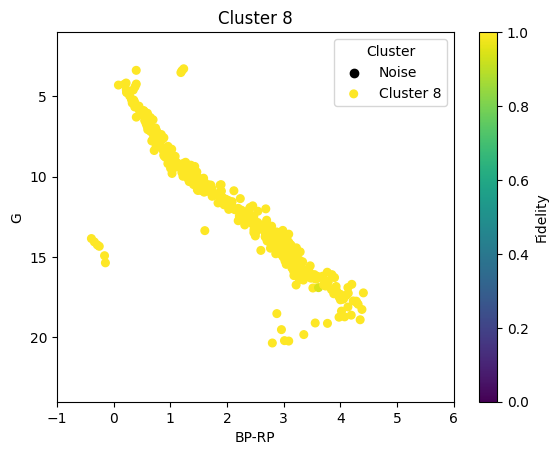

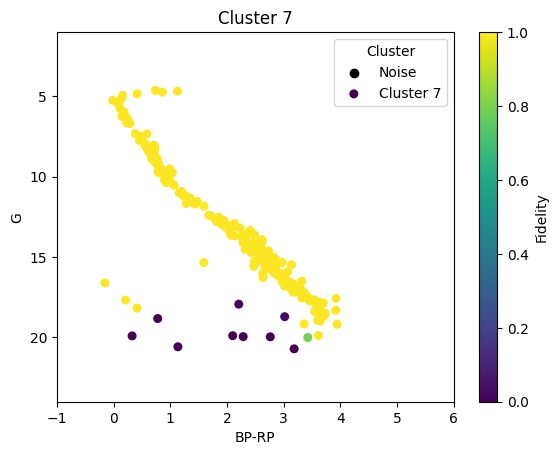

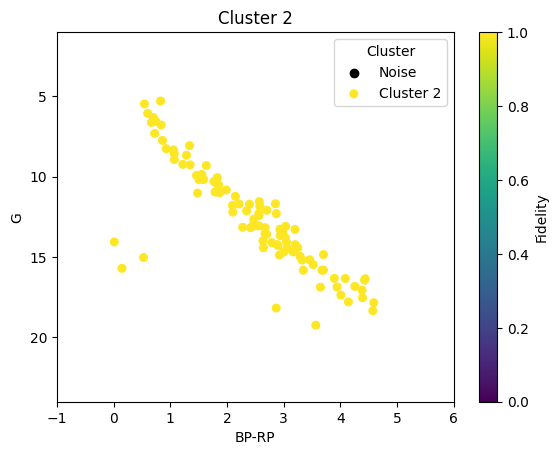

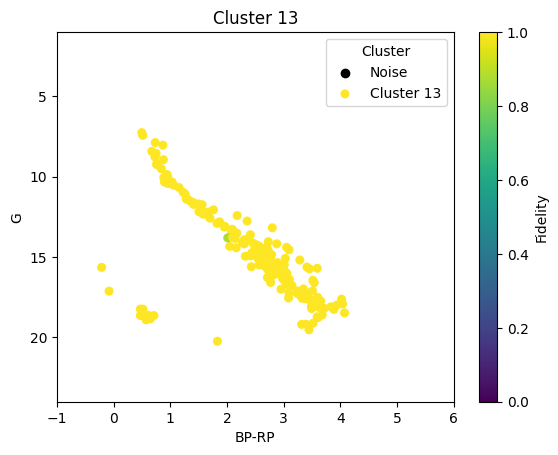

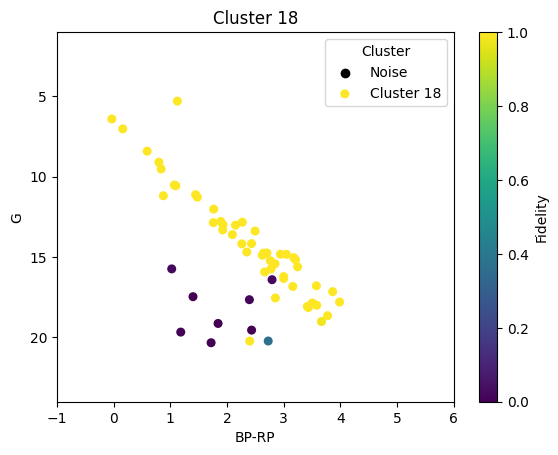

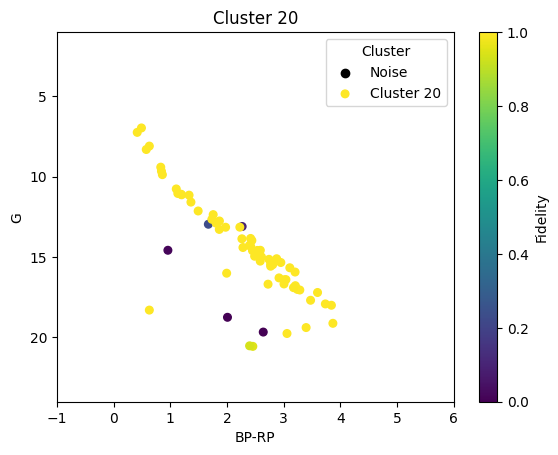

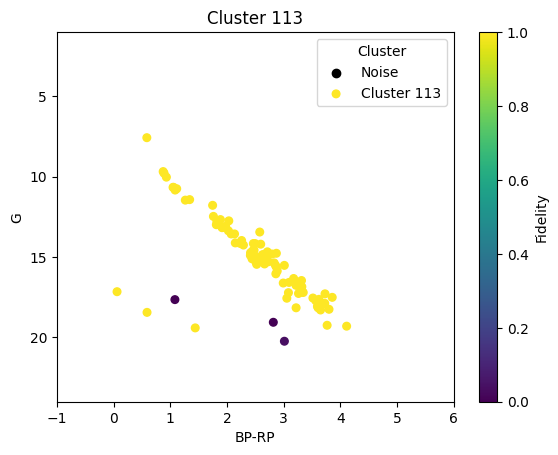

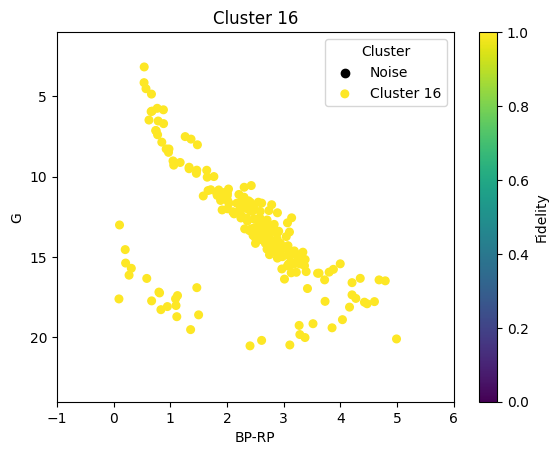

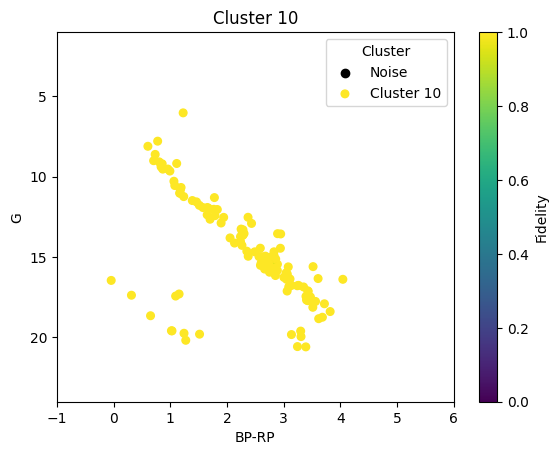

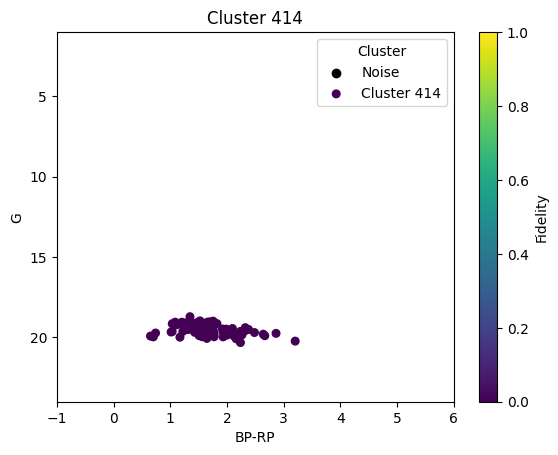

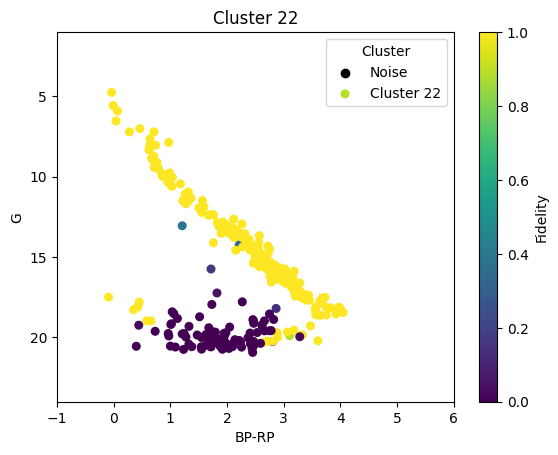

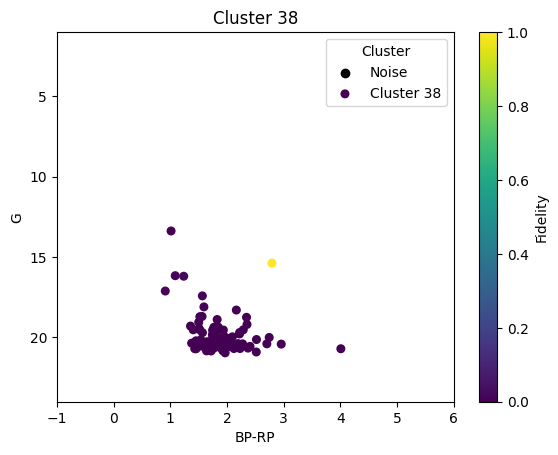

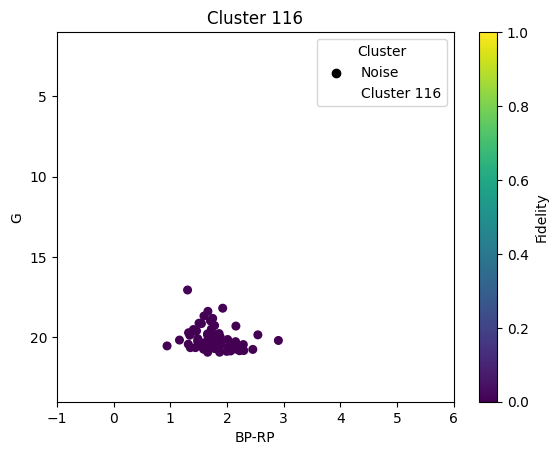

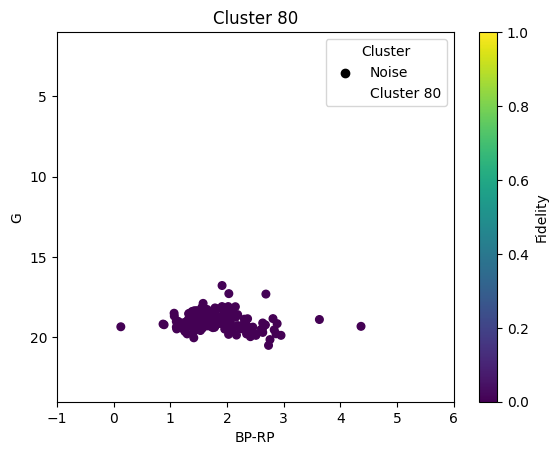

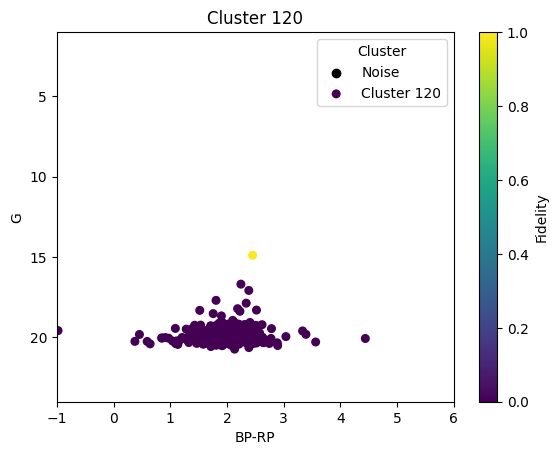

In [18]:
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(15)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Dibujar ruido en negro con alfa fijo
    noise = dff[dff['cluster'] < 0]
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['fidelity_v2']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Fidelity')

    # plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

In [19]:
# graficar en latitud y longitud galactiva

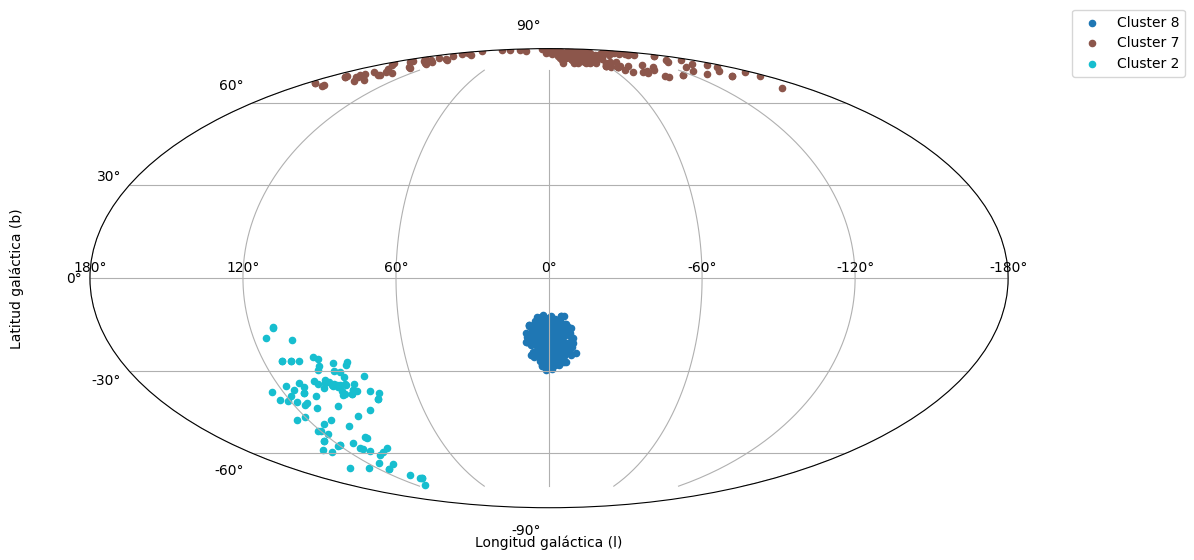

In [20]:
# Crear figura Mollweide
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')

# Graficar por cada cluster
clusters = silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values
colors = plt.cm.tab10(np.linspace(0, 1, len(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values)))  # Paleta de colores
  # Paleta de colores

for cluster, color in zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values, colors):
    subset = dff[dff['cluster'] == cluster].reset_index(drop=True)
    ax.scatter(subset['l_rad'], subset['b_rad'], s=20, alpha=1, label=f'Cluster {cluster}', color=color)

# Etiquetas y rejilla
ax.set_xticks(np.radians(np.arange(-180, 181, 60)))
ax.set_yticks(np.radians(np.arange(-90, 91, 30)))
ax.set_xticklabels(['180°', '120°', '60°', '0°', '-60°', '-120°', '-180°'])
ax.set_yticklabels(['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°'])
ax.grid(True)
ax.set_xlabel('Longitud galáctica (l)', labelpad=20)
ax.set_ylabel('Latitud galáctica (b)', labelpad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()

C:\Users\nicob\AppData\Local\Temp\ipykernel_27552\2752474401.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  sc = plt.scatter(subset['bp_rp'], subset['abs'],


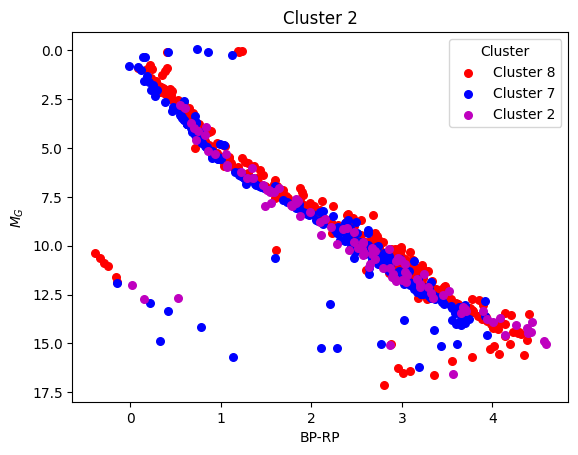

In [21]:
dic_color = dict(zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values,["red","blue","m"]))
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['abs'],
                     c=dic_color[cluster],
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel(r'$M_G$')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.gca().invert_yaxis()
plt.show()

C:\Users\nicob\AppData\Local\Temp\ipykernel_27552\2752474401.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  sc = plt.scatter(subset['bp_rp'], subset['abs'],


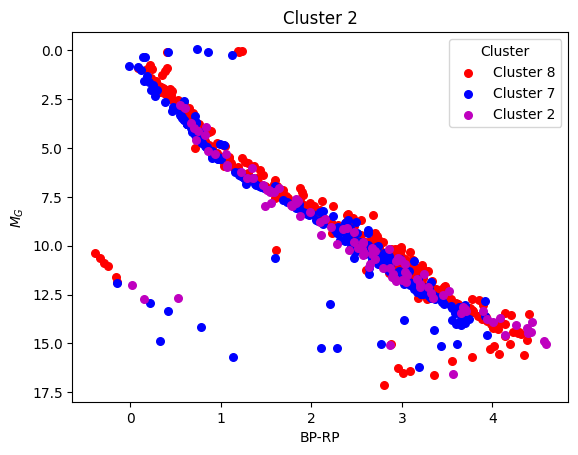

In [22]:
dic_color = dict(zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values,["red","blue","m"]))
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['abs'],
                     c=dic_color[cluster],
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel(r'$M_G$')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.gca().invert_yaxis()
plt.show()

In [23]:
df_analize = dff[dff['cluster'].isin([8,7,2])]

In [24]:
df2 = pd.read_csv("datos_resultados_modularizado/datos_clusterizados_todos_5dc3.csv")
df3 = pd.read_csv("datos_resultados_modularizado/datos_clusterizados_todos_5dc2.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'datos_resultados_modularizado/datos_clusterizados_todos_5dc3.csv'

In [ ]:
df_analize[['source_id','cluster']].merge(df2[['source_id']], how='outer', on='source_id', indicator=True)[['cluster','_merge']].value_counts(dropna=False)

cluster  _merge    
NaN      right_only    15017
8.0      left_only       437
7.0      left_only       254
2.0      left_only       101
8.0      both             69
Name: count, dtype: int64

In [ ]:
df_analize[['source_id','cluster']].merge(df3[['source_id']], how='outer', on='source_id', indicator=True)[['cluster','_merge']].value_counts(dropna=False)

cluster  _merge    
NaN      right_only    20434
8.0      left_only       437
7.0      both            229
2.0      left_only       101
8.0      both             69
7.0      left_only        25
Name: count, dtype: int64

(array([ 0.31360642,  0.        ,  0.03484516,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.03484516,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.03484516,  0.        ,
         0.        ,  0.        ,  0.        ,  0.03484516, 29.54869389]),
 array([5.60283660e-05, 3.33874941e-02, 6.67189598e-02, 1.00050426e-01,
        1.33381891e-01, 1.66713357e-01, 2.00044823e-01, 2.33376288e-01,
        2.66707754e-01, 3.00039220e-01, 3.33370686e-01, 3.66702151e-01,
        4.00033617e-01, 4.33365083e-01, 4.66696548e-01, 5.00028014e-01,
        5.33359480e-01, 5.66690946e-01, 6.00022411e-01, 6.33353877e-01,
        6.66685343e-01, 7.00016809e-01, 7.33348274e-01, 7.66679740e-01,
        8.00011206e-01, 8.33342671e-01, 8.66674137e-01, 9.00005603e-01,
        9.33337069e-01, 9.66668534e-01, 1.00000000e+00])

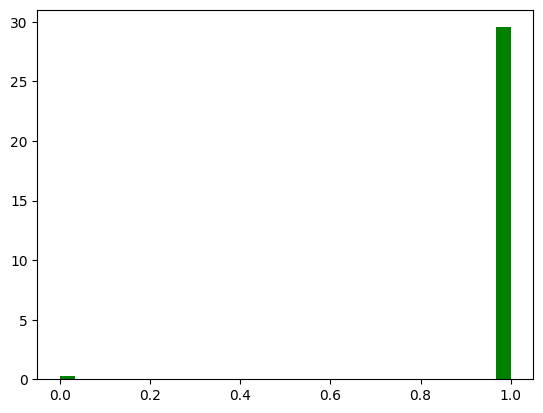

In [ ]:
plt.hist(dff[dff['cluster'].isin([2,7,8])]['fidelity_v2'], bins=30, color ='green', density=True)
# plt.hist(dff[~dff['cluster'].isin([2,7,8])]['fidelity_v2'], bins=30, color ='blue', density=True)

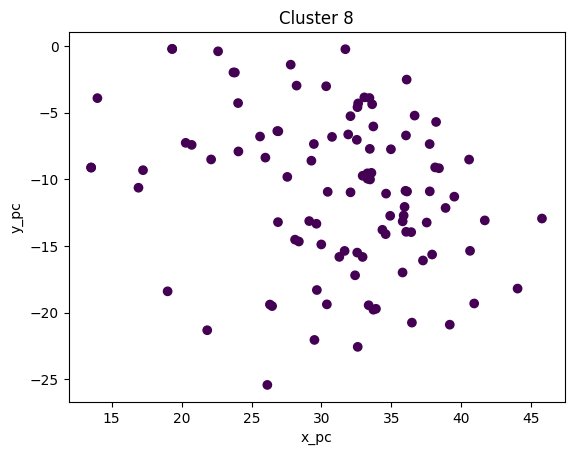

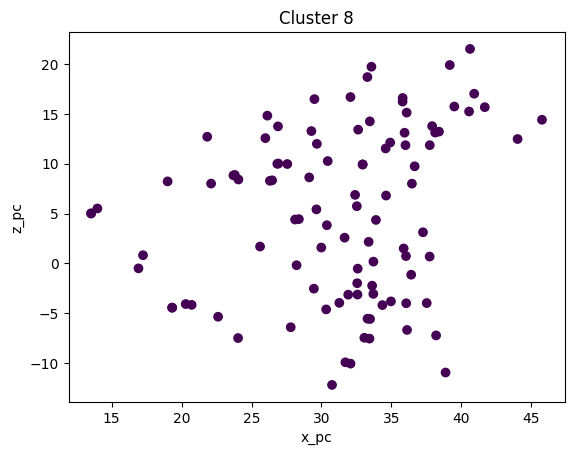

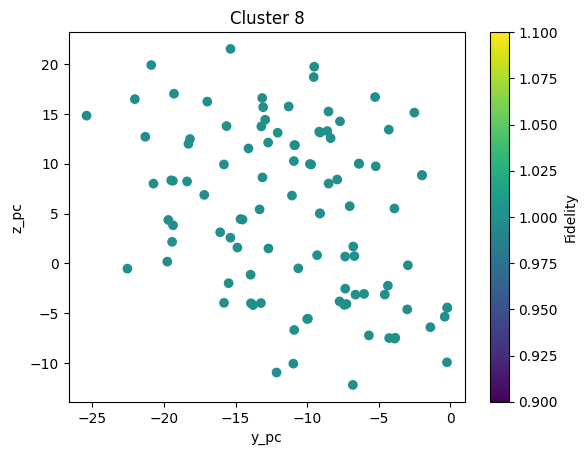

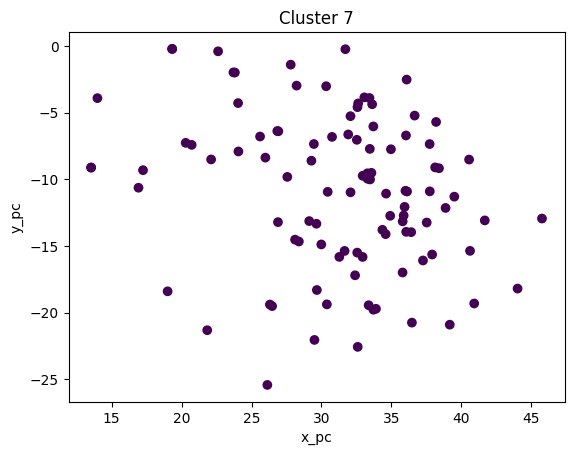

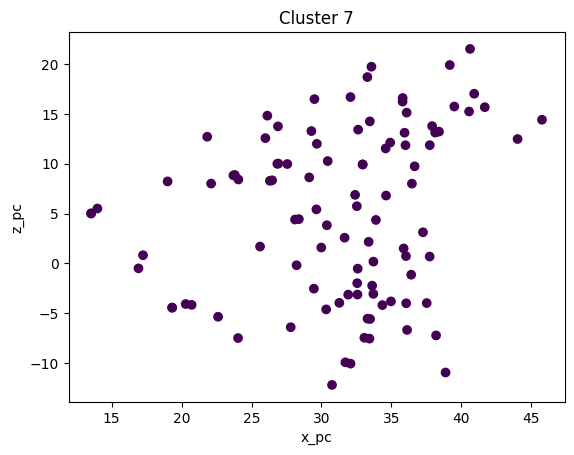

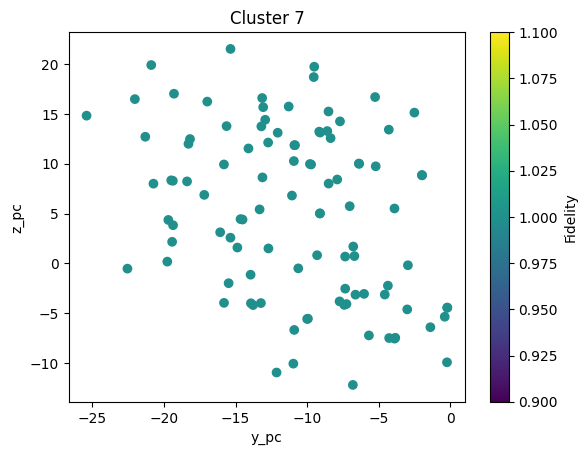

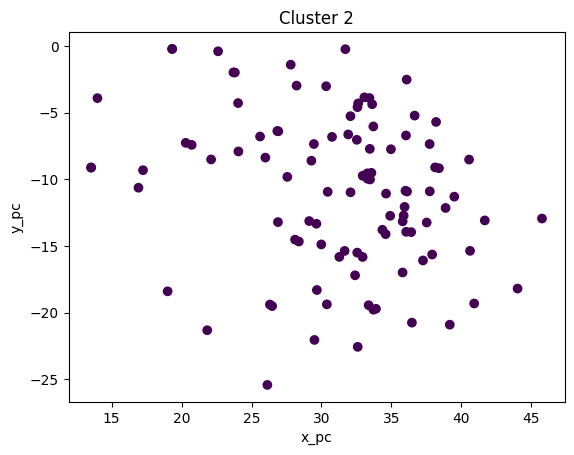

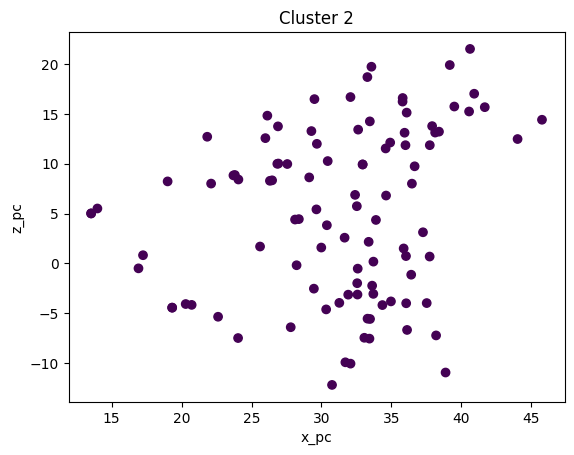

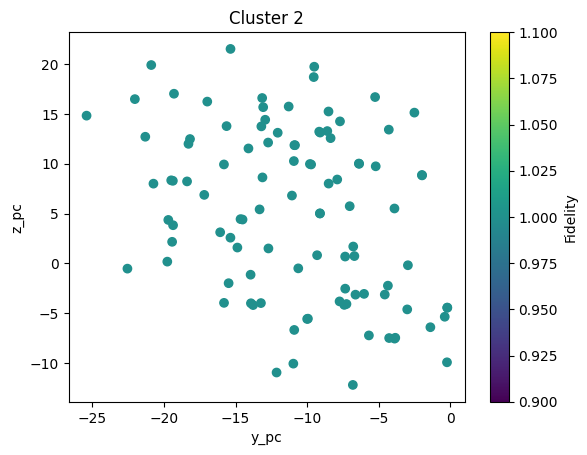

In [27]:
df_filter = dff[dff['cluster']==cluster]
combinations = [['x_pc', 'y_pc'],['x_pc', 'z_pc'],['y_pc', 'z_pc']]
for cluster in [8,7,2]:
    for comb in combinations:
        plt.figure()
        plt.scatter(df_filter[comb[0]], df_filter[comb[1]], c=df_filter['fidelity_v2'], cmap='viridis')
        plt.xlabel(comb[0])
        plt.ylabel(comb[1])
        plt.title(f'Cluster {cluster}')
    plt.colorbar(label='Fidelity')

In [31]:

fig = px.scatter_3d(
    df_filter,
    x="x_pc",
    y="y_pc",
    z="z_pc",
    color="color",
    color_continuous_scale="Viridis",
    opacity=0.7
)

fig.update_layout(
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
    title="Scatter 3D con Plotly"
)

fig.show()

In [37]:
import plotly.graph_objects as go
fig = go.Figure()
df_filter = dff[dff['cluster']==8]
# 🔵 Estrellas principales
fig.add_trace(
    go.Scatter3d(
        x=df_filter["x_pc"],
        y=df_filter["y_pc"],
        z=df_filter["z_pc"],
        mode="markers",
        marker=dict(
            size=3,
            color=df_filter["parallax"],  # o lo que uses
            colorscale="Viridis",
            opacity=0.7,
            colorbar=dict(title="Parallax [mas]")
        ),
        name="Gaia sample"
    )
)

# ⚫ Estrellas negras (más pequeñas)
fig.add_trace(
    go.Scatter3d(
        x=dff["x_pc"],
        y=dff["y_pc"],
        z=dff["z_pc"],
        mode="markers",
        marker=dict(
            size=1.5,
            color="black",
            opacity=0.9
        ),
        name="Subset especial"
    )
)

fig.update_layout(
    title="Distribución 3D Gaia + subset",
    scene=dict(
        xaxis_title="X [pc]",
        yaxis_title="Y [pc]",
        zaxis_title="Z [pc]"
    )
)

fig.show()

In [38]:
import plotly.graph_objects as go
fig = go.Figure()
df_filter = dff[dff['cluster']==2]
# 🔵 Estrellas principales
fig.add_trace(
    go.Scatter3d(
        x=df_filter["x_pc"],
        y=df_filter["y_pc"],
        z=df_filter["z_pc"],
        mode="markers",
        marker=dict(
            size=3,
            color=df_filter["parallax"],  # o lo que uses
            colorscale="Viridis",
            opacity=0.7,
            colorbar=dict(title="Parallax [mas]")
        ),
        name="Gaia sample"
    )
)

# ⚫ Estrellas negras (más pequeñas)
fig.add_trace(
    go.Scatter3d(
        x=dff["x_pc"],
        y=dff["y_pc"],
        z=dff["z_pc"],
        mode="markers",
        marker=dict(
            size=1.5,
            color="black",
            opacity=0.9
        ),
        name="Subset especial"
    )
)

fig.update_layout(
    title="Distribución 3D Gaia + subset",
    scene=dict(
        xaxis_title="X [pc]",
        yaxis_title="Y [pc]",
        zaxis_title="Z [pc]"
    )
)

fig.show()